<a href="https://colab.research.google.com/github/tamburins/ESAA-2022-/blob/main/DNN_1128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/qiangwu2023/DNN_case1_interval.git

Cloning into 'DNN_case1_interval'...
remote: Enumerating objects: 433, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 433 (delta 42), reused 26 (delta 26), pack-reused 376 (from 1)
Receiving objects: 100% (433/433), 3.11 MiB | 9.00 MiB/s, done.
Resolving deltas: 100% (290/290), done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


# 여기부터 데이터 로드


| x-variable | SUPPORT original variable          |
| ---------- | ---------------------------------- |
| **x0**     | age                                |
| **x1**     | sex                                |
| **x2**     | number of comorbidities ? 단톡방에선 race라는디           |
| **x3**     | race  ? 이게 number of comorbidities라는디?                             |
| **x4**     | diabetes                           |
| **x5**     | dementia                           |
| **x6**     | cancer (0=no, 1=yes, 2=metastatic) |
| **x7**     | heart rate                         |
| **x8**     | mean arterial blood pressure       |
| **x9**     | respiration rate                   |
| **x10**    | temperature                        |
| **x11**    | sodium                             |
| **x12**    | white blood cell count             |
| **x13**    | creatinine                         |


In [3]:
!pip install lifelines scikit-learn pandas --quiet


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.9 MB/s eta 0:00:00


In [4]:
!git clone https://github.com/qiangwu2023/DNN_case1_interval.git
%cd DNN_case1_interval/Model_Deep1


fatal: destination path 'DNN_case1_interval' already exists and is not an empty directory.
/content/DNN_case1_interval/Model_Deep1


In [5]:
!ls -R .


.:
Beta_estimate.py     g_additive.py	    iteration_linear.py
B_spline3.py	     g_deep.py		    Least_FD.py
C_estimation.py      g_linear.py	    Main3.py
data_generator.py    I_spline.py	    __pycache__
fig_g_3_t.jpeg	     iteration_additive.py  result_error_deep1_t.csv
fig_Lambda_3_t.jpeg  iteration_deep.py	    result_re_deep1_t.csv

./__pycache__:
Beta_estimate.cpython-310.pyc	g_linear.cpython-310.pyc
Beta_estimate.cpython-39.pyc	g_linear.cpython-39.pyc
B_spline3.cpython-310.pyc	I_spline.cpython-310.pyc
B_spline3.cpython-39.pyc	I_spline.cpython-39.pyc
C_estimation.cpython-310.pyc	iteration_additive.cpython-310.pyc
C_estimation.cpython-39.pyc	iteration_additive.cpython-39.pyc
data_generator.cpython-310.pyc	iteration_deep.cpython-310.pyc
data_generator.cpython-39.pyc	iteration_deep.cpython-39.pyc
g_additive.cpython-310.pyc	iteration_linear.cpython-310.pyc
g_additive.cpython-39.pyc	iteration_linear.cpython-39.pyc
g_deep.cpython-310.pyc		Least_FD.cpython-310.pyc
g_deep.cpython-39.pyc		Lea

In [6]:
# install package
!pip install numpy pandas matplotlib scipy torch


#데이터 로딩

In [8]:
!pip install pycox torchtuples --quiet

from pycox.datasets import support
import pandas as pd

# PyCox 내부 SUPPORT dataset 로드
support_df = support.read_df()

support_df.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 630.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.4/494.4 kB 17.2 MB/s eta 0:00:00
Dataset 'support' not locally available. Downloading...
Done


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event
0,82.709961,1.0,2.0,1.0,0.0,0.0,0.0,160.0,55.0,16.0,38.195309,142.0,19.000000,1.099854,30.0,1
1,79.660950,1.0,0.0,1.0,0.0,0.0,1.0,54.0,67.0,16.0,38.000000,142.0,10.000000,0.899902,1527.0,0
2,23.399990,1.0,2.0,3.0,0.0,0.0,1.0,87.0,144.0,45.0,37.296879,130.0,5.199219,1.199951,96.0,1
3,53.075989,1.0,4.0,3.0,0.0,0.0,0.0,55.0,100.0,18.0,36.000000,135.0,8.699219,0.799927,892.0,0
4,71.794983,0.0,1.0,1.0,0.0,0.0,0.0,65.0,135.0,40.0,38.593750,146.0,0.099991,0.399963,7.0,1


# EDA

### cox ph

In [9]:
import pandas as pd
from pycox.datasets import support

# 1) 데이터 불러오기
df = support.read_df()

# 2) 범주형 변수 자동 탐지 (dtype == 'object' or few unique values)
def detect_categorical(df, max_unique=20):
    cat_vars = []
    cont_vars = []
    for col in df.columns:
        if df[col].dtype == 'object':
            cat_vars.append(col)
        else:
            # 숫자형이어도 level 수가 매우 작으면 범주형일 가능성
            if df[col].nunique() <= max_unique:
                cat_vars.append(col)
            else:
                cont_vars.append(col)
    # 중복 제거
    cat_vars = list(dict.fromkeys(cat_vars))
    cont_vars = [c for c in df.columns if c not in cat_vars]
    return cat_vars, cont_vars

cat_vars, cont_vars = detect_categorical(df)

# 3) 결과 출력
print("=== Categorical Variables ===")
for col in cat_vars:
    print(f"{col}: {df[col].unique()}")

print("\n=== Continuous Variables ===")
for col in cont_vars:
    print(col)


=== Categorical Variables ===
x1: [1. 0.]
x2: [2. 0. 4. 1. 5. 3. 6. 7. 8. 9.]
x3: [1. 3. 2. 4. 0. 5.]
x4: [0. 1.]
x5: [0. 1.]
x6: [0. 1. 2.]
event: [1 0]

=== Continuous Variables ===
x0
x7
x8
x9
x10
x11
x12
x13
duration


In [10]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler


def preprocess_and_lasso(
    df,
    time_col,
    event_col,
    categorical_cols=None,
    penalizer=0.1
):
    """
    SUPPORT_df → 더미 변수 생성 → 스케일링 → Cox Lasso 적합 →
    계수만 정렬하여 출력하고,
    변환된 df와 계수 반환.

    Z/X 변수 선택은 사용자가 직접 하면 됨.
    """

    df = df.copy()

    if categorical_cols is None:
        categorical_cols = []

    # ---------------------------
    # 1) 더미 인코딩
    # ---------------------------
    df_enc = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # ---------------------------
    # 2) covariate 리스트 구성
    # ---------------------------
    covariates = [c for c in df_enc.columns if c not in [time_col, event_col]]

    # ---------------------------
    # 3) 스케일링 (연속 + 더미 모두)
    # ---------------------------
    scaler = StandardScaler()
    df_enc[covariates] = scaler.fit_transform(df_enc[covariates])

    # ---------------------------
    # 4) Cox Lasso 적합
    # ---------------------------
    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=1.0)
    cph.fit(
        df_enc[[time_col, event_col] + covariates],
        duration_col=time_col,
        event_col=event_col,
        show_progress=False
    )

    coefs = cph.params_.sort_values(key=lambda x: abs(x), ascending=False)

    print("\n===============================")
    print("   LASSO 결과 (절댓값 순 정렬)")
    print("===============================")
    for name, val in coefs.items():
        print(f"{name:25s}  {val:+.4f}")

    return {
        "df_preprocessed": df_enc,
        "coefs": coefs,
        "covariates": covariates,
        "scaler": scaler,
        "cox_model": cph
    }


In [22]:
categorical_cols = ['x1','x2','x3','x4','x5','x6']  # SUPPORT의 범주형 변수

res = preprocess_and_lasso(
    df=support_df,
    time_col="duration",
    event_col="event",
    categorical_cols=categorical_cols,
    penalizer=0.01   # 필요하면 0.05, 0.2 등으로 조절
)



   LASSO 결과 (절댓값 순 정렬)
x6_1.0                     -0.3194
x0                         +0.1851
x6_2.0                     -0.0719
x7                         -0.0711
x8                         +0.0644
x13                        +0.0545
x5_1.0                     +0.0430
x1_1.0                     -0.0248
x12                        +0.0240
x3_1.0                     -0.0113
x9                         +0.0079
x2_2.0                     +0.0056
x2_5.0                     +0.0039
x2_9.0                     -0.0005
x3_5.0                     +0.0005
x2_1.0                     +0.0000
x3_4.0                     +0.0000
x3_3.0                     -0.0000
x2_8.0                     +0.0000
x3_2.0                     +0.0000
x4_1.0                     +0.0000
x11                        -0.0000
x2_7.0                     +0.0000
x2_3.0                     -0.0000
x2_6.0                     -0.0000
x10                        +0.0000
x2_4.0                     -0.0000


## 상관성

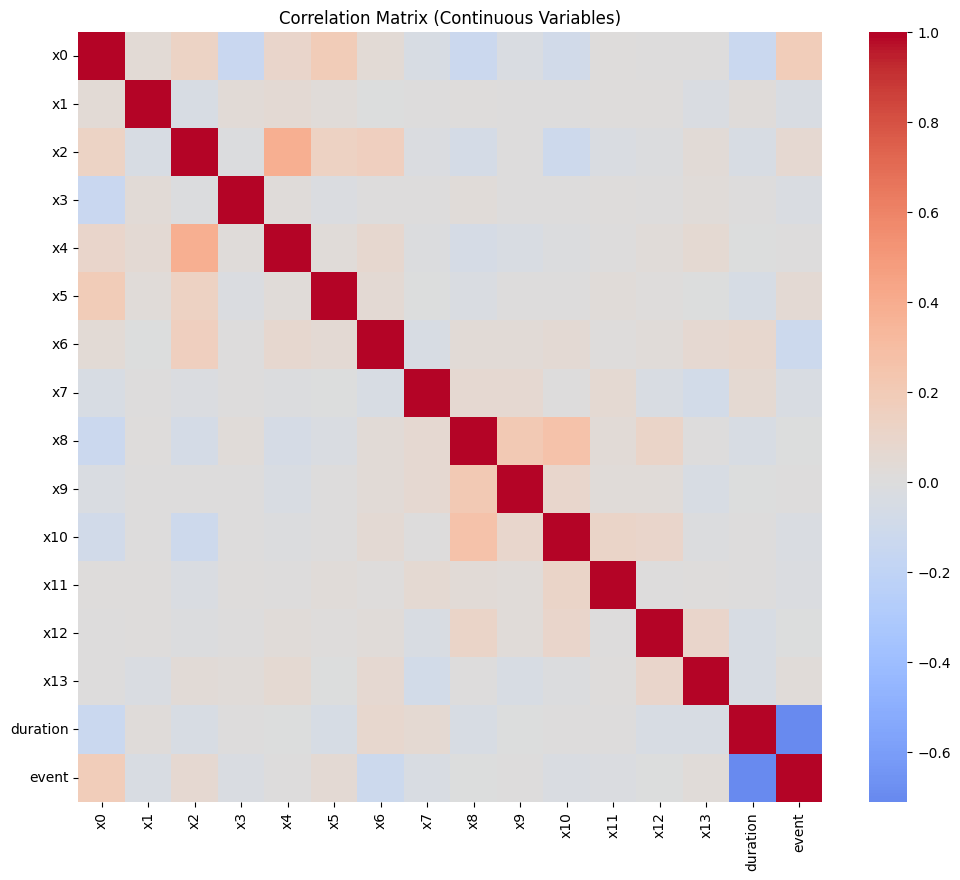

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df: 분석에 사용한 X 데이터프레임
X = support_df

# 1) 숫자형 변수만 선택
cont_cols = X.select_dtypes(include=[np.number]).columns

# 2) 상관행렬
corr = X[cont_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Continuous Variables)")
plt.show()


In [21]:
import pandas as pd
import numpy as np

X = support_df

# 숫자형 변수만 선택
cont_cols = X.select_dtypes(include=[np.number]).columns

# 상관행렬 절댓값
corr = X[cont_cols].corr().abs()

# 자기 자신 상관 제거
np.fill_diagonal(corr.values, 0)

# 기준값
threshold = 0.2

# long-format으로 변환
corr_long = (
    corr.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "corr"})
)

# threshold 이상 필터링
high_corr_pairs = corr_long.query("corr >= @threshold")

# 중복 제거 (A,B & B,A → 하나만)
high_corr_pairs = high_corr_pairs[high_corr_pairs["var1"] < high_corr_pairs["var2"]]

print(high_corr_pairs)


         var1   var2      corr
36         x2     x4  0.384352
137        x8     x9  0.212627
168       x10     x8  0.264449
239  duration  event  0.710540


In [14]:
# cramer's V ( for categorical )
import numpy as np
import scipy.stats as ss
import pandas as pd

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 네가 직접 지정한 범주형 변수 목록
cat_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

# 나머지는 연속형으로 자동 분류
cont_cols = [col for col in X.columns if col not in cat_cols]

result = pd.DataFrame(index=cat_cols, columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:
        result.loc[c1, c2] = cramers_v(X[c1], X[c2])

print(result)


          x1        x2        x3        x4        x5        x6
x1  0.999771  0.045694  0.047715  0.043796  0.026275  0.008055
x2  0.045694       1.0  0.011639  0.385472  0.136905  0.260924
x3  0.047715  0.011639       1.0  0.060701  0.027673  0.045243
x4  0.043796  0.385472  0.060701   0.99964  0.024832  0.122735
x5  0.026275  0.136905  0.027673  0.024832  0.998199  0.076777
x6  0.008055  0.260924  0.045243  0.122735  0.076777       1.0


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# df: 분석에 사용한 X 데이터프레임
X = support_df
# dummy + numerical 포함한 전체 X
X_vif = pd.get_dummies(X)

# 상수항 추가
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame()
vif_df["variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]

print(vif_df)


    variable          VIF
0      const  1364.423283
1         x0     1.134771
2         x1     1.013558
3         x2     1.259561
4         x3     1.026434
5         x4     1.194843
6         x5     1.059328
7         x6     1.063273
8         x7     1.026028
9         x8     1.155070
10        x9     1.056775
11       x10     1.114844
12       x11     1.020774
13       x12     1.033138
14       x13     1.030372
15  duration     2.043405
16     event     2.082122


## cox ph lasso

In [10]:
!pip install scikit-survival


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.0/300.0 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.0 MB/s eta 0:00:00
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.5
    Uninstalling osqp-1.0.5:
      Successfully uninstalled osqp-1.0.5


In [11]:
import pandas as pd
import numpy as np
import sksurv

from pycox.datasets import support
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv


# ----------------------------------------------------
# 1) 데이터 로딩
# ----------------------------------------------------
df = support.read_df()

time_col = "duration"
event_col = "event"

# Categorical 변수 (당신이 말한 리스트)
categorical_cols = ['x1','x2','x3','x4','x5','x6']

# 연속형 변수 (= 나머지 중 시간/이벤트 제외)
continuous_cols = [c for c in df.columns
                   if c not in categorical_cols + [time_col, event_col]]


# ----------------------------------------------------
# 2) One-hot 인코딩 + 표준화 파이프라인 구성
# ----------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("cont", StandardScaler(), continuous_cols),
    ]
)

# scikit-survival은 (event, time) 구조 필요
y = Surv.from_arrays(event=df[event_col].astype(bool),
                     time=df[time_col].astype(float))


# ----------------------------------------------------
# 3) Lasso Cox 모델 정의
# ----------------------------------------------------
# l1_ratio = 1 → Lasso
# alpha 값은 50개 자동 탐색 (glmnet 스타일)
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, n_alphas=50)


# ----------------------------------------------------
# 4) Pipeline으로 묶기
# ----------------------------------------------------
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("cox_lasso", cox_lasso)
])


# ----------------------------------------------------
# 5) Train/Test Split
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=[time_col, event_col]),
    y,
    test_size=0.2,
    random_state=42
)


# ----------------------------------------------------
# 6) 모델 학습
# ----------------------------------------------------
model.fit(X_train, y_train)

print("Lasso CoxPH 학습 완료!")


# ----------------------------------------------------
# 7) 변수 선택
# ----------------------------------------------------
import re
import re
import numpy as np

def get_selected_variables(model, categorical_cols, continuous_cols, alpha_idx=-1):
    """
    model: fitted Pipeline (preprocess + cox_lasso)
    categorical_cols: ['x1','x2','x3','x4','x5','x6']
    continuous_cols: 연속형 변수 리스트
    alpha_idx: coef_에서 사용할 열 인덱스 (기본: 마지막 alpha)
    """

    # 1) dummy + scaled 변수 전체 이름 추출
    ohe  = model.named_steps["preprocess"].named_transformers_["cat"]
    # cont = model.named_steps["preprocess"].named_transformers_["cont"]  # 필요시 사용

    dummy_feature_names = ohe.get_feature_names_out(categorical_cols)
    cont_feature_names  = continuous_cols

    feature_names = list(dummy_feature_names) + list(cont_feature_names)

    # 2) coef 가져오기 (n_features, n_alphas)
    coefs = model.named_steps["cox_lasso"].coef_

    if coefs.ndim == 2:
        # alpha 경로 중에서 하나 선택 (기본: 마지막 alpha)
        coefs_use = coefs[:, alpha_idx]
    else:
        coefs_use = coefs

    # 3) 0이 아닌 계수의 feature 이름
    selected_features = [
        name for name, coef in zip(feature_names, coefs_use)
        if coef != 0.0
    ]

    # 4) 변수 단위로 그룹핑 (dummy → 원래 변수명만 남기기)
    selected_vars = set()
    for f in selected_features:
        # 예: x1_2 → x1
        base = re.split(r"_", f)[0]
        selected_vars.add(base)

    return sorted(selected_vars)

selected = get_selected_variables(
    model=model,
    categorical_cols=['x1','x2','x3','x4','x5','x6'],
    continuous_cols=continuous_cols
)

print("선택된 변수들:")
for v in selected:
    print("-", v)



Lasso CoxPH 학습 완료!
선택된 변수들:
- x0
- x1
- x10
- x11
- x12
- x13
- x2
- x3
- x4
- x5
- x6
- x7
- x8
- x9


In [12]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cont = continuous_cols

dummy_feature_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = dummy_feature_names + cont

print(feature_names)


['x1_1.0', 'x2_1.0', 'x2_2.0', 'x2_3.0', 'x2_4.0', 'x2_5.0', 'x2_6.0', 'x2_7.0', 'x2_8.0', 'x2_9.0', 'x3_1.0', 'x3_2.0', 'x3_3.0', 'x3_4.0', 'x3_5.0', 'x4_1.0', 'x5_1.0', 'x6_1.0', 'x6_2.0', 'x0', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13']


In [13]:
import pandas as pd

coefs = model.named_steps["cox_lasso"].coef_
alpha_idx = -1  # 마지막 alpha

coef_vec = coefs[:, alpha_idx]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_vec
})

print(coef_df)


   feature      coef
0   x1_1.0 -0.055939
1   x2_1.0  0.115080
2   x2_2.0  0.125680
3   x2_3.0  0.101630
4   x2_4.0  0.161179
5   x2_5.0  0.176811
6   x2_6.0  0.082703
7   x2_7.0  0.396963
8   x2_8.0  1.561763
9   x2_9.0 -1.696374
10  x3_1.0 -0.153455
11  x3_2.0 -0.108814
12  x3_3.0 -0.208424
13  x3_4.0 -0.013140
14  x3_5.0 -0.027362
15  x4_1.0  0.021614
16  x5_1.0  0.259066
17  x6_1.0 -0.719701
18  x6_2.0 -0.302903
19      x0  0.198618
20      x7 -0.086901
21      x8  0.076076
22      x9  0.030013
23     x10 -0.003874
24     x11 -0.001100
25     x12  0.034631
26     x13  0.073210


In [14]:
import pandas as pd
import numpy as np

def get_sorted_coef_df(model, categorical_cols, continuous_cols, alpha_idx=-1):
    """
    alpha_idx: coef 행렬에서 선택할 규제 강도 index (기본: 마지막 alpha)
    """
    # ----------------------------
    # 1) feature 이름 구성
    # ----------------------------
    ohe = model.named_steps["preprocess"].named_transformers_["cat"]

    dummy_feature_names = list(ohe.get_feature_names_out(categorical_cols))
    cont_feature_names  = continuous_cols

    feature_names = dummy_feature_names + cont_feature_names

    # ----------------------------
    # 2) coef 벡터 선택
    # ----------------------------
    coefs = model.named_steps["cox_lasso"].coef_
    if coefs.ndim == 2:
        coef_vec = coefs[:, alpha_idx]   # 특정 alpha column 선택
    else:
        coef_vec = coefs

    # ----------------------------
    # 3) DataFrame 생성 + 정렬
    # ----------------------------
    df_coef = pd.DataFrame({
        "feature": feature_names,
        "coef": coef_vec,
        "abs_coef": np.abs(coef_vec)
    })

    df_sorted = df_coef.sort_values("abs_coef", ascending=False).reset_index(drop=True)

    return df_sorted
coef_sorted = get_sorted_coef_df(
    model=model,
    categorical_cols=['x1','x2','x3','x4','x5','x6'],
    continuous_cols=continuous_cols,
    alpha_idx=-1  # 마지막 alpha 사용
)

print(coef_sorted)


   feature      coef  abs_coef
0   x2_9.0 -1.696374  1.696374
1   x2_8.0  1.561763  1.561763
2   x6_1.0 -0.719701  0.719701
3   x2_7.0  0.396963  0.396963
4   x6_2.0 -0.302903  0.302903
5   x5_1.0  0.259066  0.259066
6   x3_3.0 -0.208424  0.208424
7       x0  0.198618  0.198618
8   x2_5.0  0.176811  0.176811
9   x2_4.0  0.161179  0.161179
10  x3_1.0 -0.153455  0.153455
11  x2_2.0  0.125680  0.125680
12  x2_1.0  0.115080  0.115080
13  x3_2.0 -0.108814  0.108814
14  x2_3.0  0.101630  0.101630
15      x7 -0.086901  0.086901
16  x2_6.0  0.082703  0.082703
17      x8  0.076076  0.076076
18     x13  0.073210  0.073210
19  x1_1.0 -0.055939  0.055939
20     x12  0.034631  0.034631
21      x9  0.030013  0.030013
22  x3_5.0 -0.027362  0.027362
23  x4_1.0  0.021614  0.021614
24  x3_4.0 -0.013140  0.013140
25     x10 -0.003874  0.003874
26     x11 -0.001100  0.001100


# current data status 변환 & fold

In [15]:
import numpy as np
from sklearn.model_selection import KFold

def make_folds_with_current_status(df, K, time_col, event_col, z_cols_expanded, x_cols,
                                   lam=None, seed=42):
    """
    df: 원본 데이터
    K: K-fold 개수
    time_col: 생존 시간 (duration/intxsurv 등)
    event_col: event indicator
    z_cols, x_cols: Z/X 변수
    lam: Exponential 관측 시점 lambda (None이면 자동 추정)
    """

    kf = KFold(n_splits=K, shuffle=True, random_state=seed)

    folds = []

    for fold_id, (train_idx, test_idx) in enumerate(kf.split(df)):
        df_train = df.iloc[train_idx].copy()
        df_test  = df.iloc[test_idx].copy()

        # ---- current-status 변환 ----
        cs_train = make_current_status_data(df_train,
                                            time_col=time_col,
                                            event_col=event_col,
                                            z_cols=z_cols_expanded,
                                            x_cols=x_cols_expanded,
                                            lam=lam,
                                            seed=seed + fold_id)

        cs_test = make_current_status_data(df_test,
                                           time_col=time_col,
                                           event_col=event_col,
                                           z_cols=z_cols,
                                           x_cols=x_cols,
                                           lam=lam,
                                           seed=seed + fold_id)

        folds.append({
            "fold": fold_id,
            "train": cs_train,
            "test": cs_test,
            "train_index": train_idx,
            "test_index": test_idx
        })

    return folds


In [16]:
from sklearn.preprocessing import StandardScaler

def make_current_status_data(df, time_col, event_col, z_cols, x_cols,
                             lam=None, seed=42):

    # duration, event만 결측 제거
    df = df.dropna(subset=[time_col, event_col]).copy()

    T = df[time_col].values.astype(float)
    E = df[event_col].values.astype(int)

    rng = np.random.default_rng(seed)

    # --- observation time C 생성 ---
    if lam is None:
        lam = 1 / np.mean(T)

    C_raw = rng.exponential(scale=1/lam, size=len(T))
    C = np.minimum(C_raw, T.max())

    Delta = ((T <= C) & (E == 1)).astype(int)

    df["C"] = C
    df["Delta"] = Delta
    C_max = df["C"].max()
    df["U_scaled"] = df["C"] / C_max

    # Z 변수 스케일링
    scaler = StandardScaler()
    for col in z_cols:     # z_cols MUST be expanded dummy + continuous
        df[f"Z_{col}"] = scaler.fit_transform(df[[col]])

    # X 결측 보정
    for col in x_cols:
        df[col] = df[col].fillna(-1)

    # 최종 Z 목록: 모든 Z_ 접두사 컬럼
    z_final = [c for c in df.columns if c.startswith("Z_")]

    return {
        "df": df,
        "Z_cols": z_final,
        "X_cols": x_cols,
        "time_col": time_col,
        "event_col": event_col,
        "C_max": C_max
    }


# MODELING

## Est_deep

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# --------------------------------------------------------
# Torch version of I-spline (baseline cumulative hazard)
# --------------------------------------------------------
def I_spline_torch(m, c0, U, nodevec):
    """
    I-spline basis in torch.
    c0 : (m,) learnable parameters
    U : (n,) tensor
    nodevec : numpy array of knots (m+2)
    """
    # nodevec to torch
    kv = torch.tensor(nodevec, dtype=torch.float32, device=U.device)

    # (n, m) basis matrix
    n = U.shape[0]
    basis = torch.zeros((n, m), dtype=torch.float32, device=U.device)

    for j in range(m):
        left = kv[j]
        right = kv[j+2]   # cubic I-spline for m knots
        width = right - left
        width = torch.clamp(width, min=1e-6)

        # linear I-spline construction
        b = (U - left) / width
        b = torch.clamp(b, min=0.0, max=1.0)
        basis[:, j] = b

    # Λ(U) = sum_j c0_j * I_j(U)
    return basis @ c0


# --------------------------------------------------------
# Deep Partially Linear Cox Model (DPLCM) with learnable c0
# --------------------------------------------------------
def Est_deep(train_data, X_test,
             n_layer, n_node,
             n_lr, n_epoch,
             nodevec, m):

    # 1) numpy to torch
    Z = torch.tensor(train_data['Z'], dtype=torch.float32)
    X = torch.tensor(train_data['X'], dtype=torch.float32)
    U = torch.tensor(train_data['U'], dtype=torch.float32)
    De = torch.tensor(train_data['De'], dtype=torch.float32)

    Xtest = torch.tensor(X_test, dtype=torch.float32)

    n, p_z = Z.shape
    _, p_x = X.shape

    # ----------------------------------------------------
    # 2) Network g(X)
    # ----------------------------------------------------
    class NetG(nn.Module):
        def __init__(self, p, n_layer, n_node):
            super().__init__()
            layers = []
            d = p
            for _ in range(n_layer):
                layers.append(nn.Linear(d, n_node))
                layers.append(nn.ReLU())
                d = n_node
            layers.append(nn.Linear(d, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x).squeeze(-1)

    net_g = NetG(p_x, n_layer, n_node)

    # ----------------------------------------------------
    # 3) Learnable parameters: β_z and c0
    # ----------------------------------------------------
  # 3) Learnable parameters: β_z and c0
    beta_param = torch.zeros(p_z, requires_grad=True)
    # 🔴 기존: torch.zeros(m, requires_grad=True)
    c0_param = torch.full((m,), 0.1, requires_grad=True)  # 작은 양수로 초기화

    params = list(net_g.parameters()) + [beta_param, c0_param]
    optimizer = optim.Adam(params, lr=n_lr, weight_decay=1e-4)
    eps = 1e-7

    for epoch in range(n_epoch):
        optimizer.zero_grad()

        g_train = net_g(X)
        eta = (Z * beta_param).sum(dim=1) + g_train
        eta = torch.clamp(eta, -6.0, 6.0)

        Lambda_U = I_spline_torch(m, c0_param, U, nodevec)
        # 🔴 하한 clamp 제거 또는 아주 작게만
        # Lambda_U = torch.clamp(Lambda_U, min=1e-6)

        h = Lambda_U * torch.exp(eta)
        h = torch.clamp(h, max=50.0)

        p = 1.0 - torch.exp(-h)
        p = torch.clamp(p, eps, 1 - eps)

        loglik = De * torch.log(p) + (1-De) * torch.log(1-p)
        loss = -torch.mean(loglik)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"[Epoch {epoch}] loss={loss.item():.4f}, "
                  f"c0_mean={c0_param.mean().item():.4f}")

    # ----------------------------------------------------
    # 5) Output
    # ----------------------------------------------------
    with torch.no_grad():
        g_train_hat = net_g(X).cpu().numpy()
        g_test_hat = net_g(Xtest).cpu().numpy()
        beta_hat = beta_param.cpu().numpy()
        c0_hat = c0_param.cpu().numpy()

    return {
        "g_train": g_train_hat,
        "g_test": g_test_hat,
        "Beta": beta_hat,
        "c": c0_hat
    }


## Est_linear

In [18]:
# --------------------------------------------------------
# Linear Cox Model
# --------------------------------------------------------
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# --------------------------------------------------------
# Torch I-spline (linear version)
# --------------------------------------------------------
def I_spline_torch(m, c0, U, nodevec):
    kv = torch.tensor(nodevec, dtype=torch.float32, device=U.device)
    n = U.shape[0]
    basis = torch.zeros((n, m), dtype=torch.float32, device=U.device)

    for j in range(m):
        left = kv[j]
        right = kv[j+2]
        width = torch.clamp(right - left, min=1e-6)

        b = (U - left) / width
        b = torch.clamp(b, 0.0, 1.0)
        basis[:, j] = b

    return basis @ c0   # (n,)



# --------------------------------------------------------
# SAFE exp (overflow 방지)
# --------------------------------------------------------
def safe_exp(x):
    return torch.exp(torch.clamp(x, -20, 20))



# --------------------------------------------------------
# LINEAR COX (CURRENT-STATUS) WITH LEARNABLE BASELINE
# --------------------------------------------------------
def Est_linear(
    train_data, X_test, nodevec, m,
    n_epoch=300, lr=1e-3, verbose=True
):

    # 1) numpy → torch
    Z = torch.tensor(train_data['Z'], dtype=torch.float32)
    X = torch.tensor(train_data['X'], dtype=torch.float32)
    U = torch.tensor(train_data['U'], dtype=torch.float32)
    De = torch.tensor(train_data['De'], dtype=torch.float32)

    Xtest = torch.tensor(X_test, dtype=torch.float32)

    n, p_z = Z.shape
    _, p_x = X.shape

    # --------------------------------------------------------
    # 2) Learnable parameters (Linear Cox)
    # --------------------------------------------------------
    # --------------------------------------------------------
    # 2) Learnable parameters (Linear Cox)
    # --------------------------------------------------------
    beta_z    = torch.nn.Parameter(torch.zeros(p_z))
    beta_x    = torch.nn.Parameter(torch.zeros(p_x))
    intercept = torch.nn.Parameter(torch.zeros(1))

    # baseline hazard coefficients (raw)
    raw_c0    = torch.nn.Parameter(torch.randn(m) * 0.1)

    params = [beta_z, beta_x, intercept, raw_c0]
    optimizer = optim.Adam(params, lr=lr, weight_decay=1e-6)

    eps = 1e-7

    # --------------------------------------------------------
    # 3) TRAINING LOOP
    # --------------------------------------------------------
    for epoch in range(n_epoch):

        optimizer.zero_grad()

        # ---- positive constraint ----
        c0_param = torch.nn.functional.softplus(raw_c0) + 1e-4

        # ---- Linear predictor ----
        eta = (
            (Z * beta_z).sum(dim=1) +
            (X * beta_x).sum(dim=1) +
            intercept
        )
        eta = torch.clamp(eta, -6, 6)

        # ---- Baseline cumulative hazard ----
        Lambda_raw = I_spline_torch(m, c0_param, U, nodevec)
        Lambda_U = torch.nn.functional.softplus(Lambda_raw) + 1e-6

        # ---- hazard h = Λ(U)*exp(η) ----
        h = Lambda_U * safe_exp(eta)
        h = torch.clamp(h, 0, 50.0)

        # ---- Current-status probability p = 1-exp(-h) ----
        p = -torch.expm1(-h)
        p = torch.clamp(p, eps, 1 - eps)

        # ---- log-likelihood ----
        loglik = De * torch.log(p) + (1 - De) * torch.log1p(-p)
        loss = -loglik.mean()

        # ---- NaN 방지 ----
        if torch.isnan(loss):
            print("NaN detected → skipping iteration")
            continue

        loss.backward()

        # ---- gradient clipping ----
        torch.nn.utils.clip_grad_norm_(
            [beta_z, beta_x, intercept, raw_c0], 3.0
        )

        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(f"[Epoch {epoch}] loss={loss.item():.4f}, "
                  f"c0_mean={c0_param.mean().item():.4f}, "
                  f"beta_norm={beta_z.norm().item():.4f}")

    # --------------------------------------------------------
    # 4) OUTPUT
    # --------------------------------------------------------
    with torch.no_grad():
        eta_train = (Z * beta_z).sum(dim=1) + (X * beta_x).sum(dim=1) + intercept
        eta_test  = (Xtest * beta_x).sum(dim=1) + intercept

    beta_full = np.concatenate([
    beta_z.detach().cpu().numpy(),
    beta_x.detach().cpu().numpy(),
    intercept.detach().cpu().numpy()
])
    return {
        "g_train": eta_train.cpu().numpy(),
        "g_test": eta_test.cpu().numpy(),
        "Beta": beta_full,
        "c": c0_param.detach().cpu().numpy()
    }


## Est_additive

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --------------------------------------------------------
# Univariate NN for additive model
# --------------------------------------------------------
class UnivariateNN(nn.Module):
    def __init__(self, n_layer=2, n_node=20):
        super().__init__()
        layers = []
        in_dim = 1
        for _ in range(n_layer):
            layers.append(nn.Linear(in_dim, n_node))
            layers.append(nn.ReLU())
            in_dim = n_node
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 1)
        return self.net(x).squeeze(-1)

# --------------------------------------------------------
# Additive model: g(x) = sum_j g_j(x_j)
# --------------------------------------------------------
class AdditiveNet(nn.Module):
    def __init__(self, p_x, n_layer=2, n_node=20):
        super().__init__()
        self.p_x = p_x
        self.f_list = nn.ModuleList(
            [UnivariateNN(n_layer, n_node) for _ in range(p_x)]
        )

    def forward(self, X):
        outs = [self.f_list[j](X[:, j]) for j in range(self.p_x)]
        return torch.stack(outs, dim=0).sum(dim=0)


In [20]:
def Est_additive(
        train_data,
        X_test,
        nodevec,
        m,
        n_layer=2,
        n_node=20,
        n_epoch=300,
        lr=3e-4,
        l2_penalty=1e-3,
        verbose=True
    ):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Z = torch.tensor(train_data["Z"], dtype=torch.float32, device=device)
    X = torch.tensor(train_data["X"], dtype=torch.float32, device=device)
    U = torch.tensor(train_data["U"], dtype=torch.float32, device=device)
    De = torch.tensor(train_data["De"], dtype=torch.float32, device=device)
    Xtest = torch.tensor(X_test, dtype=torch.float32, device=device)

    n, p_z = Z.shape
    _, p_x = X.shape

    # ← 여기에서 AdditiveNet 인식됨 (NameError 해결)
    net_g = AdditiveNet(p_x, n_layer=n_layer, n_node=n_node).to(device)

    beta_z = nn.Parameter(torch.zeros(p_z, dtype=torch.float32, device=device))
    intercept = nn.Parameter(torch.zeros(1, dtype=torch.float32, device=device))
    raw_c0 = nn.Parameter(torch.randn(m, dtype=torch.float32, device=device) * 0.1)

    optimizer = optim.Adam(
        list(net_g.parameters()) + [beta_z, intercept, raw_c0],
        lr=lr, weight_decay=1e-6
    )

    eps = 1e-7
    def safe_exp(x):
        return torch.exp(torch.clamp(x, -20, 20))

    for epoch in range(n_epoch):

        optimizer.zero_grad()

        c0_param = torch.nn.functional.softplus(raw_c0) + 1e-4

        Lambda_raw = I_spline_torch(m, c0_param, U, nodevec)
        Lambda_U = torch.nn.functional.softplus(Lambda_raw) + 1e-6

        g_train = net_g(X)

        eta = (Z * beta_z).sum(dim=1) + g_train + intercept
        eta = torch.clamp(eta, -6, 6)

        h = Lambda_U * safe_exp(eta)
        h = torch.clamp(h, 0, 30)

        p = -torch.expm1(-h)
        p = torch.clamp(p, eps, 1-eps)

        loglik = De * torch.log(p) + (1-De) * torch.log1p(-p)
        nll = -loglik.mean()

        l2 = beta_z.pow(2).sum() + c0_param.pow(2).sum()
        for pp in net_g.parameters():
            l2 += pp.pow(2).sum()

        loss = nll + l2_penalty * l2

        if torch.isnan(loss):
            print(f"[Additive] Epoch {epoch} | NaN → skipped")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(net_g.parameters(), 3.0)
        torch.nn.utils.clip_grad_norm_([beta_z, intercept, raw_c0], 3.0)

        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(f"[Additive] Epoch {epoch} | loss={loss.item():.4f} | c0_mean={c0_param.mean().item():.4f}")

    with torch.no_grad():
        c0_final = torch.nn.functional.softplus(raw_c0) + 1e-4

        return {
            "g_train": net_g(X).cpu().numpy(),
            "g_test": net_g(Xtest).cpu().numpy(),
            "Beta": np.concatenate([beta_z.detach().cpu().numpy(),
                                    intercept.detach().cpu().numpy()]),
            "c": c0_final.detach().cpu().numpy()
        }


In [21]:
import numpy as np
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

def train_models_kfold(df, K, time_col, event_col,
                       z_cols, x_cols,
                       make_cs_fn,
                       nodevec, m,
                       deep_config,
                       seed=42):
    """
    df: 원본 데이터
    make_cs_fn: 현재상태데이터 생성 함수 (make_current_status_data)
    deep_config: { 'n_layer': 2, 'n_node': 20, 'n_lr': 3e-4, 'n_epoch': 300 }
    """

    categorical_cols = ['x1','x2','x3','x4','x5','x6']

    # 1) dummy encoding
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # 2) categorical dummy 를 모두 Z에 넣기
    # 원래 z_cols 에 존재하던 변수 + dummy 전체
    z_cols_expanded = []

    # (a) 원래 연속형 Z 변수는 그대로 포함
    for z in z_cols:
        if z in df.columns:
            z_cols_expanded.append(z)

    # (b) dummy 를 전부 Z에 포함
    dummy_cols = [col for col in df.columns if any(col.startswith(f"{c}_") for c in categorical_cols)]
    z_cols_expanded.extend(dummy_cols)

    z_cols_expanded = sorted(z_cols_expanded)

    # 3) X = Z + duration + event 제외한 나머지
    x_cols_expanded = [
        col for col in df.columns
        if col not in z_cols_expanded + [time_col, event_col]
    ]



    kf = KFold(n_splits=K, shuffle=True, random_state=seed)

    betas_linear = []
    betas_add    = []
    betas_deep   = []

    fold_id = 0
    fold_data = []

    for train_idx, test_idx in kf.split(df):

        print(f"\n==============================")
        print(f" Fold {fold_id} ")
        print("==============================")

        df_train = df.iloc[train_idx].copy()
        df_test  = df.iloc[test_idx].copy()

        # --------------------------
        # Current-status 변환
        # --------------------------
        cs_train = make_cs_fn(df_train, time_col, event_col, z_cols_expanded, x_cols_expanded)
        cs_test  = make_cs_fn(df_test,  time_col, event_col, z_cols_expanded, x_cols_expanded)

        # --------------------------
        # X_test 준비
        # --------------------------
        X_test = cs_test['df'][x_cols_expanded].values.astype(float)

        # U, Delta 이름 통일시키기
        train_pack = {
            "Z": cs_train["df"][cs_train["Z_cols"]].values.astype(float),
            "X": cs_train["df"][x_cols_expanded].values.astype(float),
            "U": cs_train["df"]["U_scaled"].values.astype(float),   # ✅ 수정
            "De": cs_train["df"]["Delta"].values.astype(int)
        }

        # --------------------------
        # 1) Linear Cox
        # --------------------------
        print("Training Est_linear ...")
        model_linear = Est_linear(
            train_data=train_pack,
            X_test=X_test,
            nodevec=nodevec,
            m=m,
            n_epoch=200,
            lr=1e-3
        )
        betas_linear.append(model_linear["Beta"])

        # --------------------------
        # 2) Additive (PLACM)
        # --------------------------
        print("Training Est_additive ...")
        model_add = Est_additive(
            train_data=train_pack,
            X_test=X_test,
            nodevec=nodevec,
            m=m,
            n_layer=deep_config["n_layer"],
            n_node=deep_config["n_node"],
            n_epoch=deep_config["n_epoch"],
            lr=deep_config["n_lr"]
        )
        betas_add.append(model_add["Beta"])

        # --------------------------
        # 3) Deep (DPLCM)
        # --------------------------
        print("Training Est_deep ...")
        model_deep = Est_deep(
            train_data=train_pack,
            X_test=X_test,
            n_layer=deep_config["n_layer"],
            n_node=deep_config["n_node"],
            n_lr=deep_config["n_lr"],
            n_epoch=deep_config["n_epoch"],
            nodevec=nodevec,
            m=m
        )
        betas_deep.append(model_deep["Beta"])

        test_df_cs = cs_test["df"].copy()
        test_df_cs["g_add"] = model_add["g_test"]
        test_df_cs["g_deep"] = model_deep["g_test"]

        fold_data.append({
          "linear": model_linear,
          "add": model_add,
          "deep": model_deep,
          "test_idx": test_idx,
          "test_cs_df": test_df_cs,
          "C_max":  cs_test["C_max"]   # ✅ 추가

        })


        fold_id += 1

    return {
      "linear": np.array(betas_linear),
      "add": np.array(betas_add),
      "deep": np.array(betas_deep),
      "fold_data": fold_data,
      "z_cols_expanded": z_cols_expanded,
      "x_cols_expanded": x_cols_expanded
}


In [22]:
def plot_beta_kfold(betas, model_name, z_labels=None):
    """
    betas: (K, p) array
    """
    K, p = betas.shape

    plt.figure(figsize=(12, 5))
    for k in range(K):
        plt.plot(range(p), betas[k], marker='o', alpha=0.7, label=f"Fold {k}")

    if z_labels is not None:
        plt.xticks(range(p), z_labels, rotation=45)
    else:
        plt.xticks(range(p))

    plt.title(f"{model_name}: Fold-wise Beta Estimates")
    plt.grid(True)
    plt.legend()
    plt.show()


## 실행

In [ ]:
deep_cfg = {
    "n_layer": 2,
    "n_node": 30,
    "n_lr": 3e-4,
    "n_epoch": 300
}

results_fin = train_models_kfold(
    df=support_df,
    K=5,
    time_col="duration",
    event_col="event",
    z_cols=['x0','x6','x7'],
    x_cols=[c for c in support_df.columns if c not in ["duration","event","x0","x6","x7"]],
    make_cs_fn=make_current_status_data,
    nodevec=np.linspace(0,1,7),
    m=5,
    deep_config=deep_cfg
)



 Fold 0 
Training Est_linear ...
[Epoch 0] loss=0.7249, c0_mean=0.6781, beta_norm=0.0046
[Epoch 50] loss=0.6553, c0_mean=0.6612, beta_norm=0.1611
[Epoch 100] loss=0.6476, c0_mean=0.6464, beta_norm=0.2425
[Epoch 150] loss=0.6431, c0_mean=0.6342, beta_norm=0.2984
Training Est_additive ...
[Additive] Epoch 0 | loss=7.9955 | c0_mean=0.7041
[Additive] Epoch 50 | loss=7.9760 | c0_mean=0.6966
[Additive] Epoch 100 | loss=7.9597 | c0_mean=0.6892
[Additive] Epoch 150 | loss=7.9449 | c0_mean=0.6819
[Additive] Epoch 200 | loss=0.8132 | c0_mean=0.6756
[Additive] Epoch 250 | loss=0.7870 | c0_mean=0.6699
Training Est_deep ...
[Epoch 0] loss=5.3254, c0_mean=0.0998
[Epoch 50] loss=1.0760, c0_mean=0.0905
[Epoch 100] loss=0.8642, c0_mean=0.0780
[Epoch 150] loss=0.7787, c0_mean=0.0660
[Epoch 200] loss=0.7482, c0_mean=0.0543
[Epoch 250] loss=0.7258, c0_mean=0.0427

 Fold 1 
Training Est_linear ...
[Epoch 0] loss=0.7246, c0_mean=0.6811, beta_norm=0.0046
[Epoch 50] loss=0.6567, c0_mean=0.6649, beta_norm=0.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beta_with_ci(results_dict, var_index, var_name, model_order=None):
    """
    results_dict: {"deep": betas, "linear": betas, "add": betas}
                  각 betas shape = (K, p)
    var_index: 시각화할 변수 인덱스 (0~p-1)
    var_name: 시각화할 변수 이름(str)
    """

    if model_order is None:
        model_order = ["deep", "linear", "add"]

    colors = {
        "deep": "blue",
        "linear": "green",
        "add": "orange"
    }

    markers = {
        "deep": "s",
        "linear": "o",
        "add": "^"
    }

    K = list(results_dict.values())[0].shape[0]  # number of folds
    x_positions = np.arange(1, K+1)

    plt.figure(figsize=(8,5))

    for model in model_order:
        betas = results_dict[model][:, var_index]

        mean_beta = betas  # fold별 추정치
        se_beta = betas.std() / np.sqrt(K)  # folds 간 분산으로 CI 구성 (논문 스타일)
        ci_lower = mean_beta - 1.96 * se_beta
        ci_upper = mean_beta + 1.96 * se_beta

        # 같은 위치에 겹치지 않도록 offset
        offset = {"deep": -0.12, "linear": 0, "add": 0.12}[model]

        plt.errorbar(
            x_positions + offset,  # fold index + offset
            mean_beta,
            yerr=[mean_beta - ci_lower, ci_upper - mean_beta],
            fmt=markers[model],
            color=colors[model],
            capsize=4,
            label=model.upper()
        )

    plt.title(f"β for {var_name} across folds")
    plt.xlabel("Fold")
    plt.ylabel("Estimate of β")
    plt.xticks(x_positions)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()


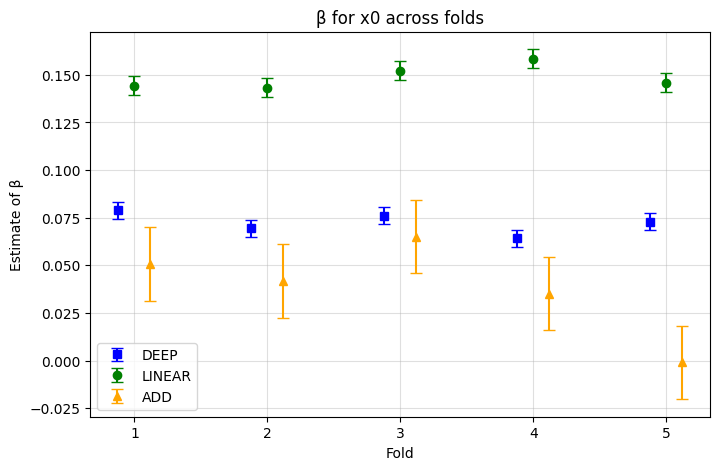

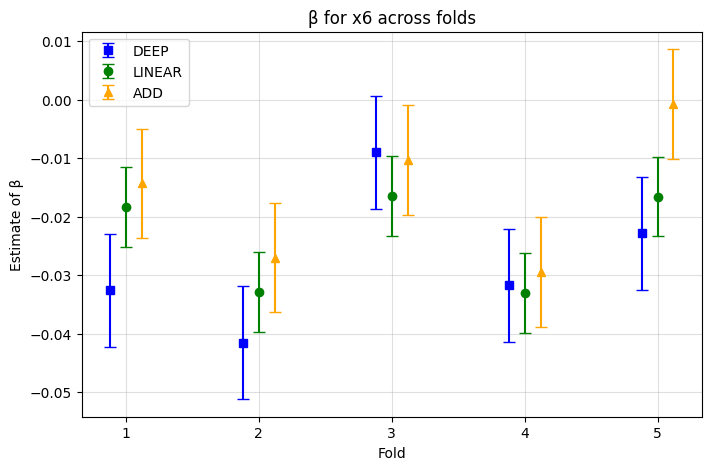

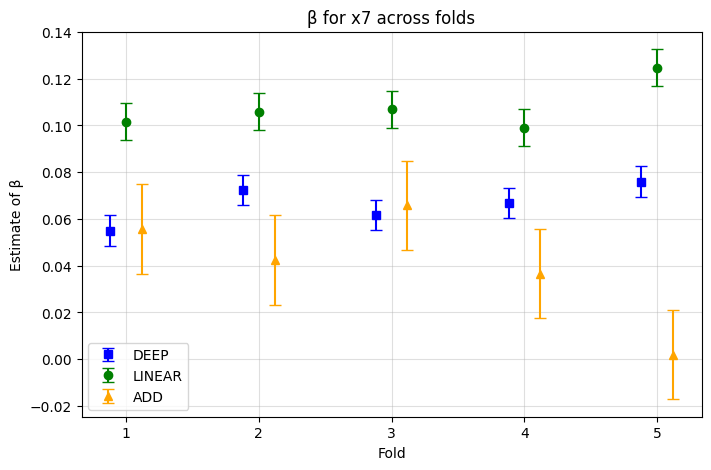

In [ ]:
plot_beta_with_ci(
    results_dict = results_fin,
    var_index = 0,
    var_name = "x0"
)

plot_beta_with_ci(
    results_dict = results_fin,
    var_index = 1,
    var_name = "x6"
)

plot_beta_with_ci(
    results_dict = results_fin,
    var_index = 2,
    var_name = "x7"
)

## 실행2

In [ ]:
deep_cfg = {
    "n_layer": 2,
    "n_node": 30,
    "n_lr": 3e-4,
    "n_epoch": 300
}

results_multi = train_models_kfold(
    df=support_df,
    K=5,
    time_col="duration",
    event_col="event",
    z_cols=["x0","x1","x4","x6","x13"],
    x_cols=[c for c in support_df.columns if c not in ["duration","event","x0","x1","x4","x6","x13"]],
    make_cs_fn=make_current_status_data,
    nodevec=np.linspace(0,1,7),
    m=5,
    deep_config=deep_cfg
)



 Fold 0 
Training Est_linear ...
[Epoch 0] loss=0.7233, c0_mean=0.6778, beta_norm=0.0046
[Epoch 50] loss=0.6580, c0_mean=0.6631, beta_norm=0.1379
[Epoch 100] loss=0.6484, c0_mean=0.6449, beta_norm=0.2394
[Epoch 150] loss=0.6434, c0_mean=0.6307, beta_norm=0.3010
Training Est_additive ...
[Additive] Epoch 0 | loss=8.0045 | c0_mean=0.7050
[Additive] Epoch 50 | loss=7.9849 | c0_mean=0.6975
[Additive] Epoch 100 | loss=7.9684 | c0_mean=0.6900
[Additive] Epoch 150 | loss=7.9546 | c0_mean=0.6827
[Additive] Epoch 200 | loss=7.9428 | c0_mean=0.6756
[Additive] Epoch 250 | loss=7.9328 | c0_mean=0.6685
Training Est_deep ...
[Epoch 0] loss=1.5973, c0_mean=0.0997
[Epoch 50] loss=0.8321, c0_mean=0.0907
[Epoch 100] loss=0.7784, c0_mean=0.0820
[Epoch 150] loss=0.7499, c0_mean=0.0731
[Epoch 200] loss=0.7293, c0_mean=0.0641
[Epoch 250] loss=0.7124, c0_mean=0.0551

 Fold 1 
Training Est_linear ...
[Epoch 0] loss=0.7248, c0_mean=0.6833, beta_norm=0.0046
[Epoch 50] loss=0.6568, c0_mean=0.6685, beta_norm=0.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beta_with_ci(results_dict, var_index, var_name, model_order=None):
    """
    results_dict: {"deep": betas, "linear": betas, "add": betas}
                  각 betas shape = (K, p)
    var_index: 시각화할 변수 인덱스 (0~p-1)
    var_name: 시각화할 변수 이름(str)
    """

    if model_order is None:
        model_order = ["deep", "linear", "add"]

    colors = {
        "deep": "blue",
        "linear": "green",
        "add": "orange"
    }

    markers = {
        "deep": "s",
        "linear": "o",
        "add": "^"
    }

    K = list(results_dict.values())[0].shape[0]  # number of folds
    x_positions = np.arange(1, K+1)

    plt.figure(figsize=(8,5))

    for model in model_order:
        betas = results_dict[model][:, var_index]

        mean_beta = betas  # fold별 추정치
        se_beta = betas.std() / np.sqrt(K)  # folds 간 분산으로 CI 구성 (논문 스타일)
        ci_lower = mean_beta - 1.96 * se_beta
        ci_upper = mean_beta + 1.96 * se_beta

        # 같은 위치에 겹치지 않도록 offset
        offset = {"deep": -0.12, "linear": 0, "add": 0.12}[model]

        plt.errorbar(
            x_positions + offset,  # fold index + offset
            mean_beta,
            yerr=[mean_beta - ci_lower, ci_upper - mean_beta],
            fmt=markers[model],
            color=colors[model],
            capsize=4,
            label=model.upper()
        )

    plt.title(f"β for {var_name} across folds")
    plt.xlabel("Fold")
    plt.ylabel("Estimate of β")
    plt.xticks(x_positions)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()


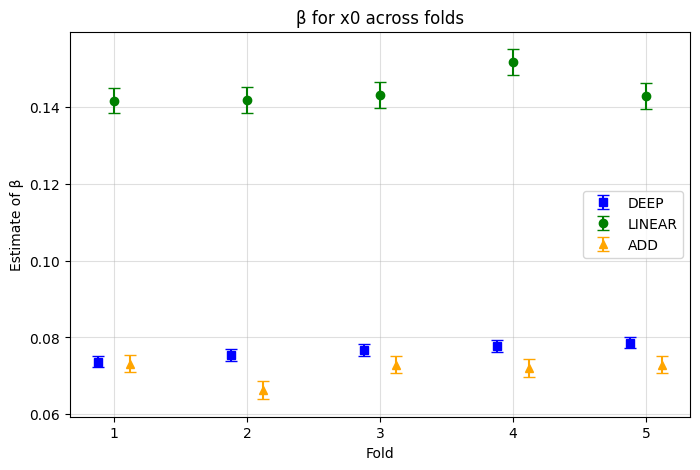

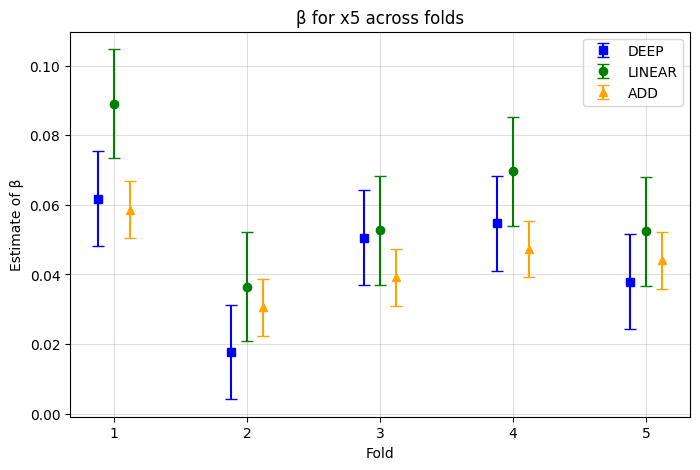

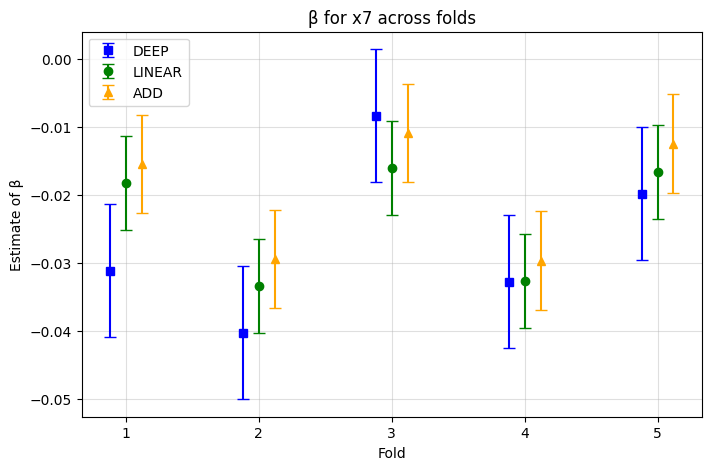

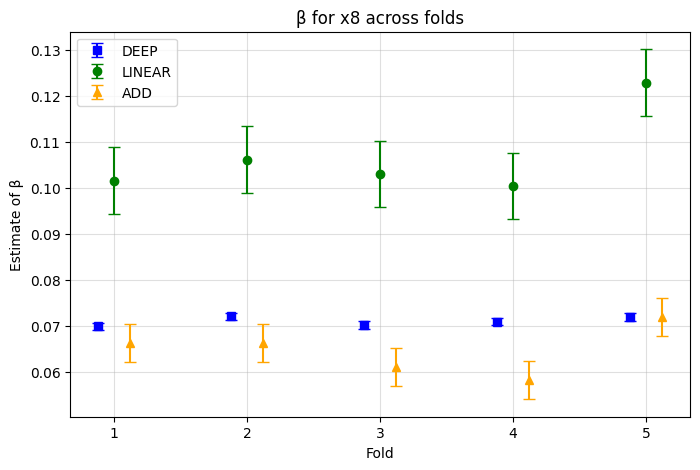

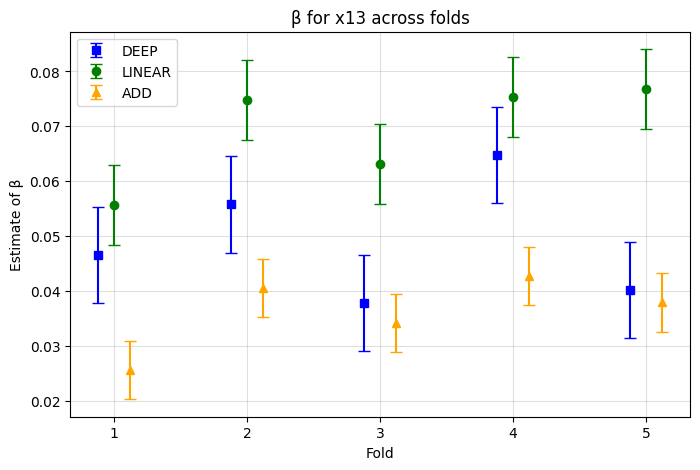

In [ ]:
plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 0,
    var_name = "x0"
)


plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 1,
    var_name = "x5"
)

plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 2,
    var_name = "x7"
)
plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 3,
    var_name = "x8"
)

plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 4,
    var_name = "x13"
)

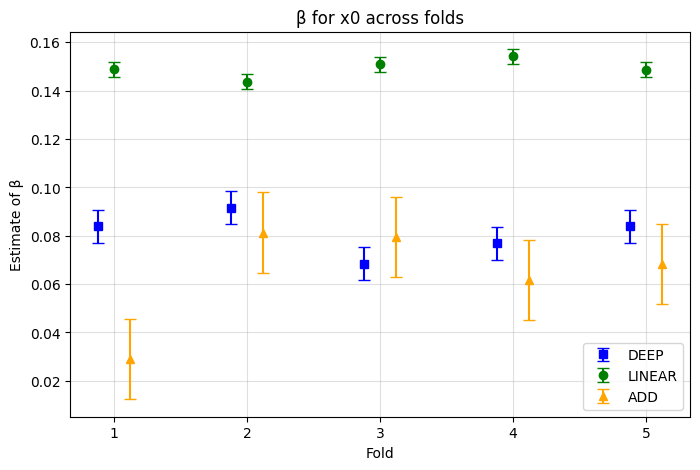

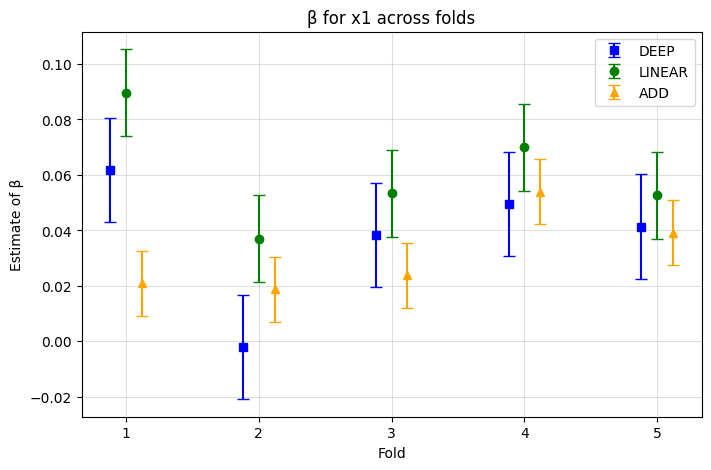

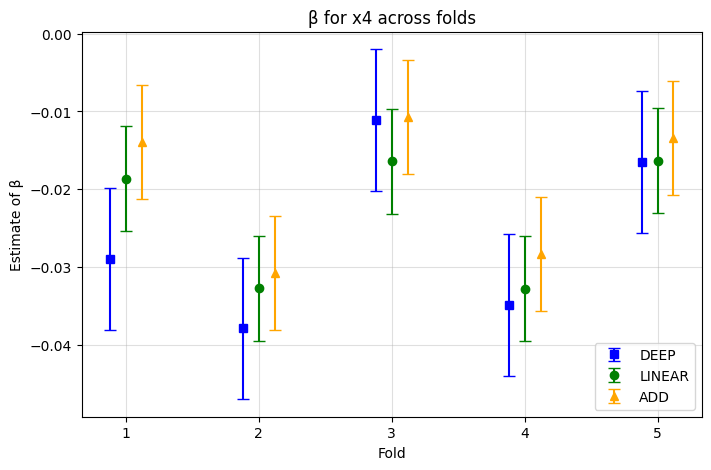

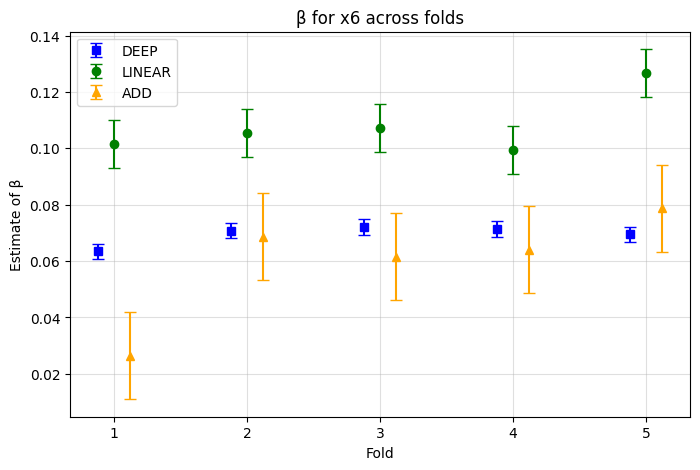

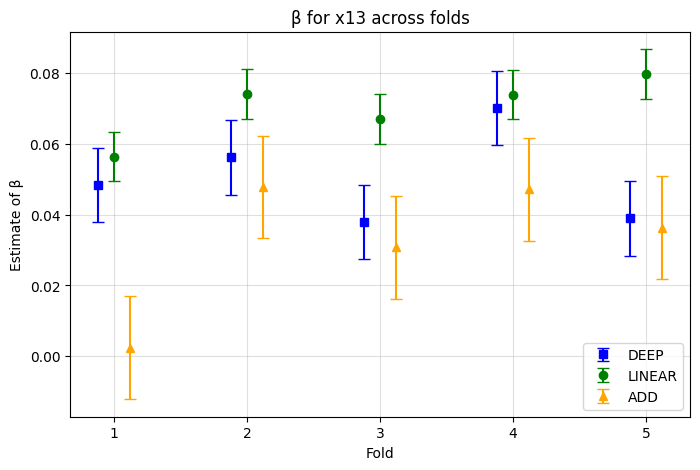

In [ ]:
plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 0,
    var_name = "x0"
)


plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 1,
    var_name = "x1"
)

plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 2,
    var_name = "x4"
)
plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 3,
    var_name = "x6"
)

plot_beta_with_ci(
    results_dict = results_multi,
    var_index = 4,
    var_name = "x13"
)

## delta - duration quantile 시각화

In [ ]:
def I_spline_eval(t_grid, c0, nodevec):
    t_grid = torch.tensor(t_grid, dtype=torch.float32)
    c0_t = torch.tensor(c0, dtype=torch.float32)
    kv = torch.tensor(nodevec, dtype=torch.float32)

    m = len(c0)
    n = len(t_grid)

    basis = torch.zeros((n, m))
    for j in range(m):
        left = kv[j]
        right = kv[j+2]
        width = max(float(right-left), 1e-6)
        b = (t_grid - left) / width
        b = torch.clamp(b, 0, 1)
        basis[:, j] = b

    Lambda = basis @ c0_t
    return Lambda.numpy()


In [ ]:
def eta_linear(sample, beta_full):
    pz = len(sample["Z"])
    px = len(sample["X"])

    beta_z = beta_full[:pz]
    beta_x = beta_full[pz:pz+px]
    intercept = beta_full[-1]

    return np.dot(beta_z, sample["Z"]) + np.dot(beta_x, sample["X"]) + intercept


def eta_additive(sample, beta_vec, g_add):
    pz = len(sample["Z"])
    beta_z = beta_vec[:pz]
    intercept = beta_vec[-1]
    return np.dot(beta_z, sample["Z"]) + g_add + intercept


def eta_deep(sample, beta_z, g_deep):
    return np.dot(beta_z, sample["Z"]) + g_deep


In [ ]:
def survival_curve(t_grid_original, eta, c0, nodevec, C_max):
    # 원래 시간 → [0,1]로 스케일 후 I-spline 계산
    t_scaled = t_grid_original / C_max
    Lambda_t = I_spline_eval(t_scaled, c0, nodevec)
    h_t = Lambda_t * np.exp(eta)
    S_t = np.exp(-h_t)
    return S_t

In [ ]:
def plot_panel(ax, sample,
               model_linear, model_add, model_deep,
               nodevec, t_grid,
               z_cols, x_cols, C_max):

    s = {
        "Z": sample[[f"Z_{z}" for z in z_cols]].values.astype(float),
        "X": sample[x_cols].values.astype(float),
        "C": sample["C"],
        "Delta": sample["Delta"]
    }
    gA = sample["g_add"]
    gD = sample["g_deep"]

    eta_L = eta_linear(s, model_linear["Beta"])
    eta_A = eta_additive(s, model_add["Beta"], gA)
    eta_D = eta_deep(s, model_deep["Beta"], gD)

    S_L = survival_curve(t_grid, eta_L, model_linear["c"], nodevec, C_max)
    S_A = survival_curve(t_grid, eta_A, model_add["c"], nodevec, C_max)
    S_D = survival_curve(t_grid, eta_D, model_deep["c"], nodevec, C_max)

    ax.plot(t_grid, S_D, label="DPLCM", color="blue")
    ax.plot(t_grid, S_L, label="CPH",   color="green")
    ax.plot(t_grid, S_A, label="PLACM", color="orange")

    ax.axvline(s["C"], linestyle="--", color="black")
    ax.set_ylim(0, 1.05)
    ax.grid(True)

In [ ]:
def plot_figure4(fold_id, results, z_cols, x_cols,
                 nodevec=np.linspace(0,1,7),
                 T_max=None):

    fold = results["fold_data"][fold_id]
    C_max = fold["C_max"]

    model_linear = fold["linear"]
    model_add    = fold["add"]
    model_deep   = fold["deep"]

    test_df = fold["test_cs_df"].copy()

    D1 = test_df[test_df["Delta"] == 1].copy()
    D0 = test_df[test_df["Delta"] == 0].copy()

    if T_max is None:
        T_max = test_df["C"].max() * 1.2
    t_grid = np.linspace(0, T_max, 300)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for j,q in enumerate([0.25,0.5,0.75]):
        sample,_ = select_case(D1, q)
        plot_panel(axes[0][j], sample,
                   model_linear, model_add, model_deep,
                   nodevec, t_grid, z_cols, x_cols, C_max)
    for j,q in enumerate([0.25,0.5,0.75]):
        sample,_ = select_case(D0, q)
        plot_panel(axes[1][j], sample,
                   model_linear, model_add, model_deep,
                   nodevec, t_grid, z_cols, x_cols, C_max)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()


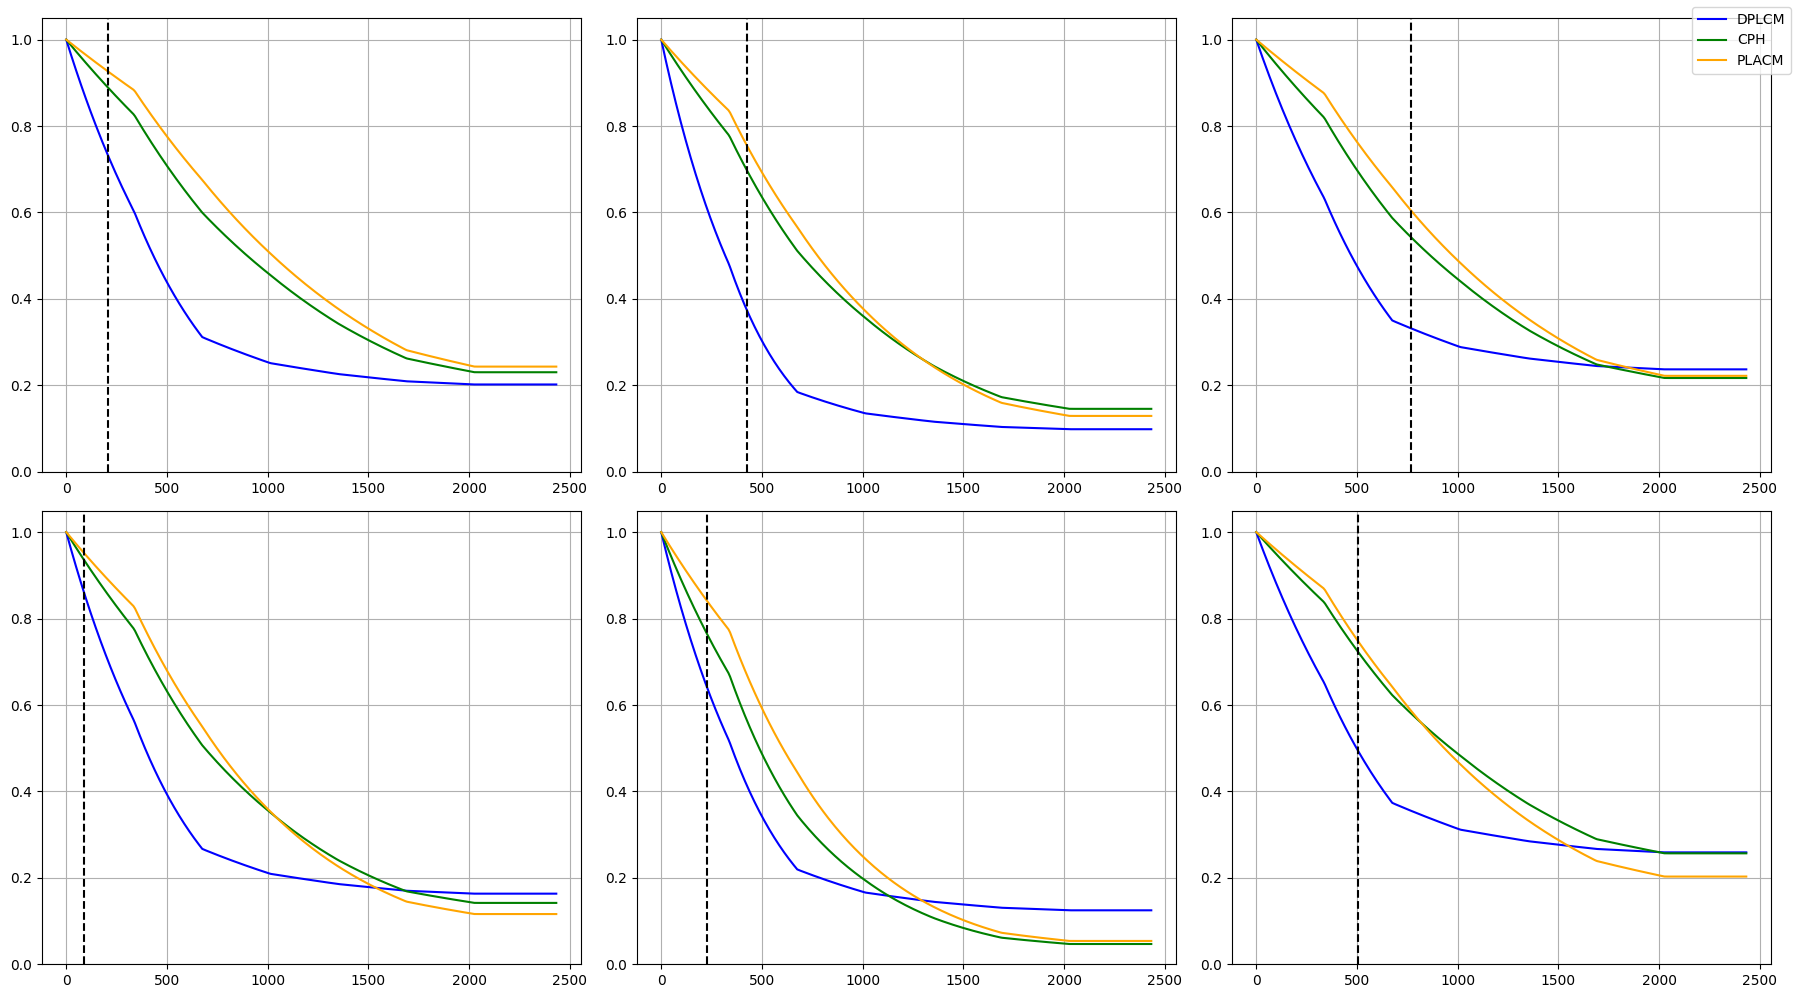

In [ ]:
plot_figure4(
    fold_id=0,
    results=results_fin,
    z_cols=results_fin["z_cols_expanded"],
    x_cols=results_fin["x_cols_expanded"]
)


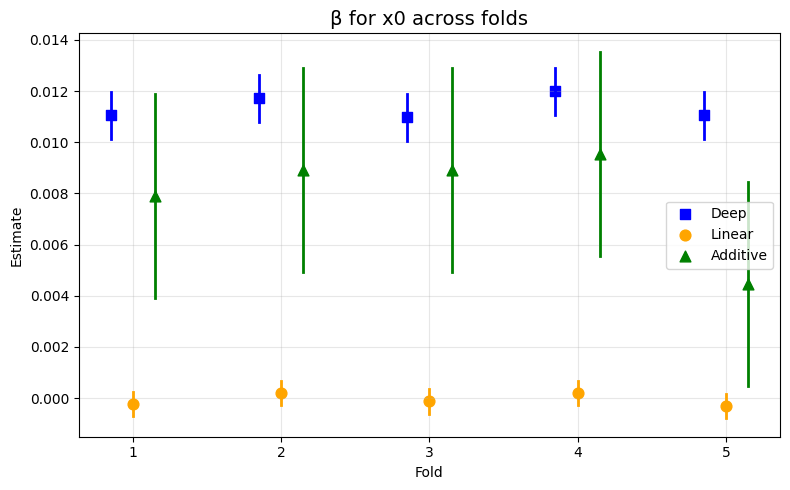

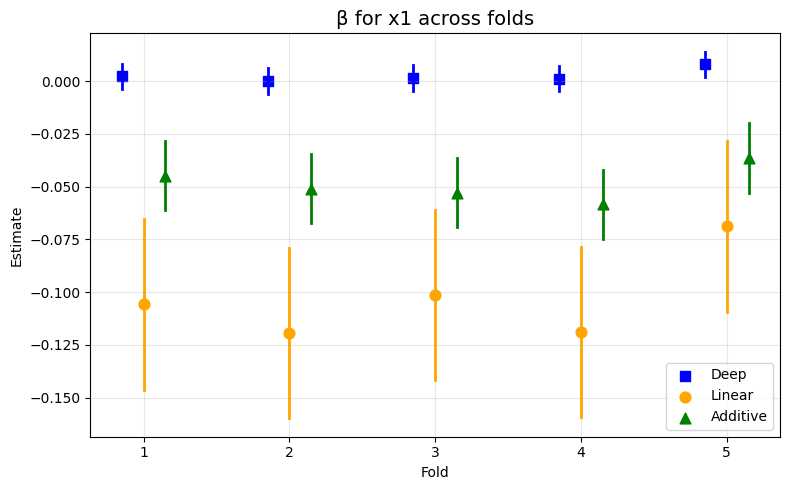

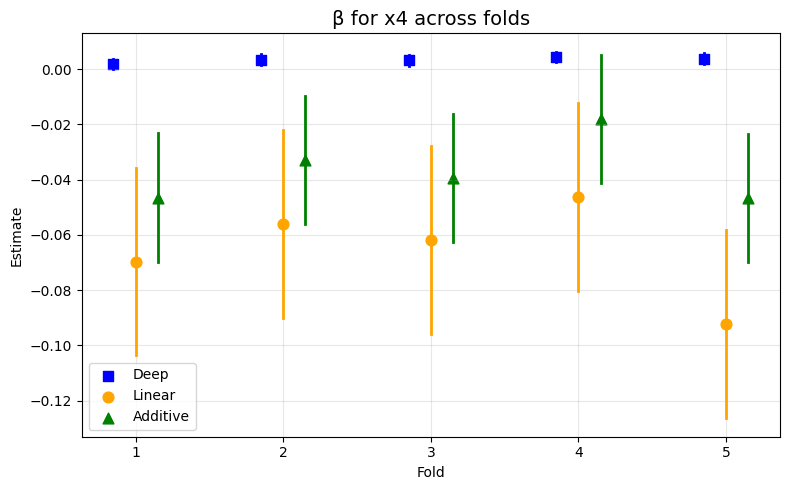

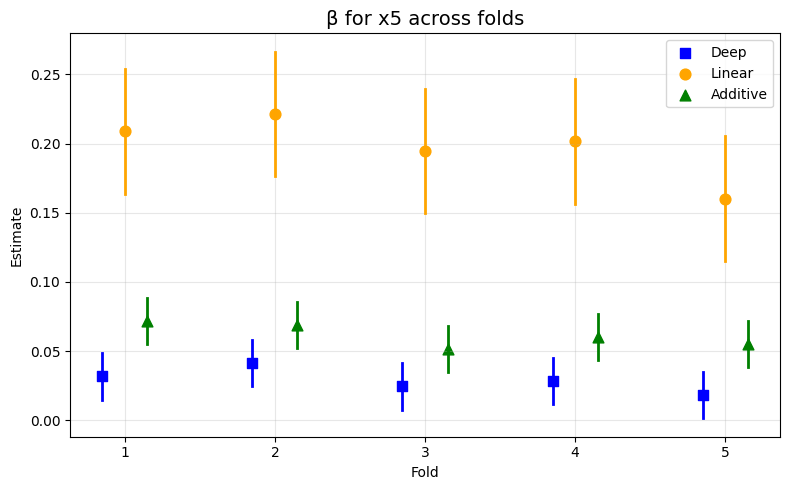

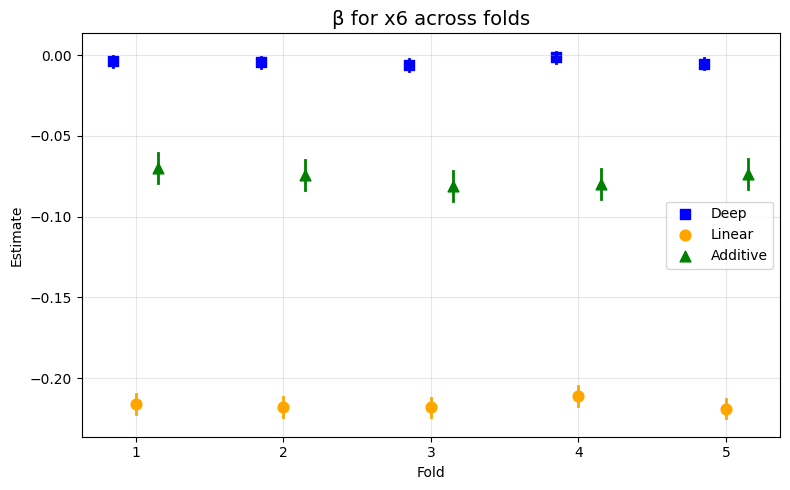

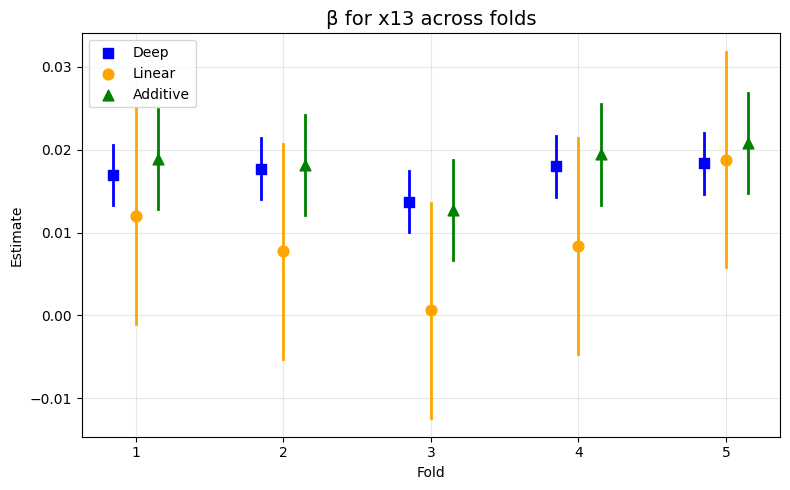

In [ ]:

#참고용
p_z = len(Z_cols)

beta_de_Z = np.vstack([b[:p_z] for b in beta_de_all])
beta_L_Z  = np.vstack([b[:p_z] for b in beta_L_all])
beta_A_Z  = np.vstack([b[:p_z] for b in beta_A_all])

plot_beta_ci_folds_offset(beta_de_Z, beta_L_Z, beta_A_Z, Z_cols)


# 성능

In [ ]:
import numpy as np

# ---------- 1) I-spline on numpy  (U_scaled 입력) ----------
def I_spline_eval_vec(u_scaled, c0, nodevec):
    """
    u_scaled : array-like, in [0,1]
    c0       : (m,) baseline 계수 (model['c'])
    nodevec  : knots (길이 m+2)
    """
    u = np.asarray(u_scaled, dtype=float)
    kv = np.asarray(nodevec, dtype=float)
    m = len(c0)
    n = len(u)

    basis = np.zeros((n, m))
    for j in range(m):
        left = kv[j]
        right = kv[j+2]
        width = max(right - left, 1e-6)
        b = (u - left) / width
        b = np.clip(b, 0.0, 1.0)
        basis[:, j] = b

    Lambda = basis @ c0   # (n,)
    return Lambda


# ---------- 2) 각 모델별 eta, S(U) 계산 함수 ----------
def predict_S_at_U_fold(fold, results, nodevec, model_name):
    """
    fold      : results['fold_data'][k]
    results   : train_models_kfold 반환값 (z_cols_expanded, x_cols_expanded 포함)
    nodevec   : I-spline knot 벡터 (np.linspace(0,1,7) 등)
    model_name: 'linear', 'add', 'deep'
    return    : S_hat(U_i) (길이 n_test)
    """
    df = fold["test_cs_df"].copy()
    C_max = fold["C_max"]

    z_cols = results["z_cols_expanded"]
    x_cols = results["x_cols_expanded"]

    # Z, X, 관측시점 U
    Z = df[[f"Z_{z}" for z in z_cols]].values.astype(float)
    X = df[x_cols].values.astype(float)
    U = df["C"].values.astype(float)

    # U를 학습 때와 동일하게 [0,1]로 스케일
    U_scaled = U / C_max

    model = fold[model_name]
    c0 = model["c"]          # (m,)

    n_test, pz = Z.shape
    px = X.shape[1]

    # ----- eta 계산 -----
    if model_name == "linear":
        beta_full = model["Beta"]              # (pz + px + 1,)
        beta_z = beta_full[:pz]
        beta_x = beta_full[pz:pz+px]
        intercept = beta_full[-1]
        eta = Z @ beta_z + X @ beta_x + intercept

    elif model_name == "add":  # PLACM
        beta_vec = model["Beta"]               # (pz + 1,)
        beta_z = beta_vec[:pz]
        intercept = beta_vec[-1]
        g_test = model["g_test"].reshape(-1)   # (n_test,)
        eta = Z @ beta_z + g_test + intercept

    elif model_name == "deep": # DPLCM
        beta_z = model["Beta"]                 # (pz,)
        g_test = model["g_test"].reshape(-1)
        eta = Z @ beta_z + g_test

    else:
        raise ValueError("model_name must be 'linear', 'add', or 'deep'.")

    # ----- baseline Λ(U) & S(U) -----
    Lambda_U = I_spline_eval_vec(U_scaled, c0, nodevec)   # (n_test,)
    h_U = Lambda_U * np.exp(eta)
    S_U = np.exp(-h_U)

    return S_U


# ---------- 3) 논문 방식의 censoring 예측 평가 ----------
def evaluate_censor_prediction(results, nodevec, event_col="event"):
    """
    results  : train_models_kfold 출력
    nodevec  : I-spline knot (np.linspace(0,1,7)와 동일하게)
    event_col: 원래 event indicator 컬럼명 (SUPPORT에서는 'event')
    """

    model_names = ["deep", "linear", "add"]  # DPLCM, CPH, PLACM

    # 집계용 dict
    summary = {
        m: {
            "N_total": 0,
            "N_true_cens": 0,
            "N_pred_cens": 0,
            "N_correct_cens": 0
        }
        for m in model_names
    }

    # fold별로 test set disjoint → 그대로 합산하면 전체 test에 대한 성능
    for fold in results["fold_data"]:
        df = fold["test_cs_df"].copy()

        # TRUE censoring indicator: 원래 right-censored 여부
        # event == 0 이면 censoring
        true_cens = (df[event_col] == 0).astype(int).values
        n = len(df)

        for m in model_names:
            S_U = predict_S_at_U_fold(fold, results, nodevec, m)
            # 논문 정의: S(U) > 0.5 이면 "right-censored로 예측"
            pred_cens = (S_U > 0.5).astype(int)

            summary[m]["N_total"]      += n
            summary[m]["N_true_cens"]  += true_cens.sum()
            summary[m]["N_pred_cens"]  += pred_cens.sum()
            summary[m]["N_correct_cens"] += ((true_cens == 1) & (pred_cens == 1)).sum()

    # 전체 test 기준 지표 계산
    out = {}
    for m in model_names:
        N_tot  = summary[m]["N_total"]
        N_true = summary[m]["N_true_cens"]
        N_pred = summary[m]["N_pred_cens"]
        N_corr = summary[m]["N_correct_cens"]

        true_rate = N_true / N_tot           # 실제 censoring rate
        pred_rate = N_pred / N_tot           # 예측 censoring rate
        out[m] = {
            "true_censor_rate": true_rate,
            "pred_censor_rate": pred_rate,
            "n_true_censored": N_true,
            "n_correct_on_censored": N_corr
        }
    return out


In [ ]:
nodevec = np.linspace(0, 1, 7)  # 학습 때 쓴 것과 동일해야 함

eval_res = evaluate_censor_prediction(results3, nodevec=nodevec)

for model, v in eval_res.items():
    print(f"\n[{model.upper()}]")
    print(f"  실제 censoring rate      = {v['true_censor_rate']*100:.2f}%")
    print(f"  예측 censoring rate      = {v['pred_censor_rate']*100:.2f}%")
    print(f"  right-censored 개수      = {v['n_true_censored']}")
    print(f"  그 중 맞게 'censored' 예측 = {v['n_correct_on_censored']}")



[DEEP]
  실제 censoring rate      = 31.97%
  예측 censoring rate      = 52.99%
  right-censored 개수      = 2837
  그 중 맞게 'censored' 예측 = 1609

[LINEAR]
  실제 censoring rate      = 31.97%
  예측 censoring rate      = 74.21%
  right-censored 개수      = 2837
  그 중 맞게 'censored' 예측 = 2235

[ADD]
  실제 censoring rate      = 31.97%
  예측 censoring rate      = 75.06%
  right-censored 개수      = 2837
  그 중 맞게 'censored' 예측 = 2200


In [ ]:
def evaluate_censor_prediction_full(results, nodevec, event_col="event"):
    model_names = ["deep", "linear", "add"]

    summary = {
        m: {
            "N_total": 0,
            "N_true_cens": 0,
            "N_pred_cens": 0,
            "N_correct_cens": 0,
            "true_labels": [],
            "pred_labels": [],
            "pred_probs": []
        }
        for m in model_names
    }

    for fold in results["fold_data"]:
        df = fold["test_cs_df"].copy()

        # TRUE censoring indicator
        true_cens = (df[event_col] == 0).astype(int).values

        for m in model_names:
            S_U = predict_S_at_U_fold(fold, results, nodevec, m)
            pred_cens = (S_U > 0.5).astype(int)

            summary[m]["N_total"] += len(df)
            summary[m]["N_true_cens"] += true_cens.sum()
            summary[m]["N_pred_cens"] += pred_cens.sum()
            summary[m]["N_correct_cens"] += ((true_cens == 1) & (pred_cens == 1)).sum()

            summary[m]["true_labels"].extend(true_cens.tolist())
            summary[m]["pred_labels"].extend(pred_cens.tolist())
            summary[m]["pred_probs"].extend(S_U.tolist())

    # 결과 정리
    out = {}
    for m in model_names:
        N_tot = summary[m]["N_total"]
        N_true = summary[m]["N_true_cens"]
        N_pred = summary[m]["N_pred_cens"]
        N_corr = summary[m]["N_correct_cens"]

        out[m] = {
            "true_censor_rate": N_true / N_tot,
            "pred_censor_rate": N_pred / N_tot,
            "n_true_censored": N_true,
            "n_correct_on_censored": N_corr,
            "true_labels": np.array(summary[m]["true_labels"]),
            "pred_labels": np.array(summary[m]["pred_labels"]),
            "pred_probs": np.array(summary[m]["pred_probs"])
        }
    return out


In [ ]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score
)

def compute_metrics(true_labels, pred_labels, pred_probs):
    tn, fp, fn, tp = confusion_matrix(true_labels, pred_labels).ravel()

    metrics = {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Accuracy": accuracy_score(true_labels, pred_labels),
        "Precision": precision_score(true_labels, pred_labels, zero_division=0),
        "Recall": recall_score(true_labels, pred_labels, zero_division=0),
        "F1": f1_score(true_labels, pred_labels, zero_division=0),
        "ROC_AUC": roc_auc_score(true_labels, pred_probs),
        "PR_AUC": average_precision_score(true_labels, pred_probs)
    }
    return metrics
def evaluate_all_metrics(results, nodevec):
    base = evaluate_censor_prediction_full(results, nodevec)
    res = {}

    for model in ["deep", "linear", "add"]:
        b = base[model]

        metrics = compute_metrics(
            b["true_labels"],
            b["pred_labels"],
            b["pred_probs"]
        )

        res[model] = {
            **b,            # censor predictions 정보 포함
            **metrics      # 성능 지표 추가
        }
    return res


In [ ]:
nodevec = np.linspace(0, 1, 7)

eval_all = evaluate_all_metrics(results_fin, nodevec)

for model, m in eval_all.items():
    print(f"\n[{model.upper()}] ===================")
    print(f"True censoring rate  = {m['true_censor_rate']:.3f}")
    print(f"Pred censoring rate  = {m['pred_censor_rate']:.3f}")
    print(f"TP={m['TP']}  FP={m['FP']}  FN={m['FN']}  TN={m['TN']}")
    print(f"Accuracy = {m['Accuracy']:.3f}")
    print(f"Precision = {m['Precision']:.3f}")
    print(f"Recall = {m['Recall']:.3f}")
    print(f"F1 = {m['F1']:.3f}")
    print(f"ROC AUC = {m['ROC_AUC']:.3f}")
    print(f"PR AUC = {m['PR_AUC']:.3f}")



[DEEP] ===================
True censoring rate  = 0.320
Pred censoring rate  = 0.507
TP=1531  FP=2971  FN=1306  TN=3065
Accuracy = 0.518
Precision = 0.340
Recall = 0.540
F1 = 0.417
ROC AUC = 0.538
PR AUC = 0.335

[LINEAR] ===================
True censoring rate  = 0.320
Pred censoring rate  = 0.747
TP=2245  FP=4386  FN=592  TN=1650
Accuracy = 0.439
Precision = 0.339
Recall = 0.791
F1 = 0.474
ROC AUC = 0.546
PR AUC = 0.343

[ADD] ===================
True censoring rate  = 0.320
Pred censoring rate  = 0.681
TP=1985  FP=4057  FN=852  TN=1979
Accuracy = 0.447
Precision = 0.329
Recall = 0.700
F1 = 0.447
ROC AUC = 0.517
PR AUC = 0.327
